# Microlearning Implementation — Song et al. (2024)

**Prospective configuration** (Song, Millidge, Salvatori, Lukasiewicz, Xu & Bogacz, *Nature Neuroscience* 2024).

We drop predictive coding into the Neuromatch *microlearning* comparison and run it head-to-head with **backpropagation** and **Hebbian** learning on MNIST (identical MLP). PC uses the paper's energy relaxation: clamp the output to the target, relax the hidden activity, then a local Hebbian weight update.

> **How to run:** needs `torch`, `torchvision`, and MNIST at `~/Downloads/data` (auto-downloads if missing). Runs on Apple-MPS / CUDA / CPU. Cells run top-to-bottom; the console output and figures below were produced by our run.


In [ ]:
"""Run backprop / Hebbian / Predictive-Coding experiments on MNIST and emit a
self-contained visual HTML report following the notebook's section flow."""
import contextlib, io, base64, warnings, datetime
import numpy as np, torch, torchvision
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
torch.manual_seed(1); np.random.seed(1)

# palette (cohesive with the report: BP blue / Hebbian orange / PC green)
C = {"backprop":"#2a78d6", "Hebbian":"#eb6834", "Predictive Coding":"#12a06f",
     "grid":"#eaedf4", "ink":"#141c28", "muted":"#5d6b82"}
from matplotlib.patheffects import withStroke
_GLOW=[withStroke(linewidth=3.2, foreground="white")]
plt.rcParams.update({"figure.dpi":150,"savefig.dpi":150,"font.size":11.5,"font.family":"DejaVu Sans",
    "axes.edgecolor":"#d7dce6","axes.linewidth":1.1,"axes.labelcolor":C["muted"],"axes.labelsize":11,
    "text.color":C["ink"],"xtick.color":C["muted"],"ytick.color":C["muted"],
    "xtick.labelsize":10.5,"ytick.labelsize":10,"legend.fontsize":9.5,
    "axes.grid":True,"grid.color":C["grid"],"grid.linewidth":1,"axes.axisbelow":True,
    "figure.facecolor":"white","savefig.facecolor":"white"})

def _beautify(fig):
    """Uniform premium pass: despine, soft ticks, bold left titles, glow lines, white-edged bars."""
    for ax in fig.axes:
        img = len(ax.images) > 0
        for s in ("top","right"): ax.spines[s].set_visible(False)
        if img:
            for s in ("left","bottom"): ax.spines[s].set_visible(False)
        ax.tick_params(length=0)
        t = ax.get_title(loc="center")
        if t:
            ax.set_title("", loc="center")                    # clear centre title first
            ax.set_title(t, fontweight="bold", loc="left", fontsize=12, color=C["ink"], pad=8)
        for ln in ax.get_lines():
            if ln.get_linestyle() == "-" and ln.get_linewidth() < 2.2: ln.set_linewidth(2.4)
            ln.set_solid_capstyle("round"); ln.set_path_effects(_GLOW)
            if ln.get_marker() not in (None, "None", ""):
                ln.set_markeredgecolor("white"); ln.set_markeredgewidth(1.4)
        import matplotlib.patches as mp
        for p in ax.patches:
            if isinstance(p, mp.Rectangle):
                p.set_edgecolor("white"); p.set_linewidth(1.4)
        leg = ax.get_legend()
        if leg: leg.set_frame_on(False)

def fig_b64(fig):
    fig.tight_layout(); _beautify(fig)
    b=io.BytesIO(); fig.savefig(b,format="png",bbox_inches="tight",facecolor="white")
    plt.close(fig); return base64.b64encode(b.getvalue()).decode()

# ---------------- support code (from notebook) ----------------
def download_mnist(train_prop=0.8, keep_prop=0.5):
    vp=1-train_prop; dp=1-keep_prop
    tf=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,),(0.3081,))])
    with contextlib.redirect_stdout(io.StringIO()):
        ftr=torchvision.datasets.MNIST(root="./data/",train=True,download=True,transform=tf)
        fte=torchvision.datasets.MNIST(root="./data/",train=False,download=True,transform=tf)
    tr,va,_=torch.utils.data.random_split(ftr,[train_prop*keep_prop,vp*keep_prop,dp])
    te,_=torch.utils.data.random_split(fte,[keep_prop,dp]); return tr,va,te

NUM_INPUTS=784; NUM_OUTPUTS=10
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self,num_inputs=NUM_INPUTS,num_hidden=100,num_outputs=NUM_OUTPUTS,activation_type="sigmoid",bias=False):
        super().__init__()
        self.num_inputs=num_inputs;self.num_hidden=num_hidden;self.num_outputs=num_outputs
        self.activation_type=activation_type;self.bias=bias
        self.lin1=torch.nn.Linear(num_inputs,num_hidden,bias=bias)
        self.lin2=torch.nn.Linear(num_hidden,num_outputs,bias=bias)
        self.init_lin1=self.lin1.weight.data.clone()
        self.act={"sigmoid":torch.nn.Sigmoid(),"tanh":torch.nn.Tanh(),"relu":torch.nn.ReLU(),"identity":torch.nn.Identity()}[activation_type.lower()]
        self.activation=self.act; self.softmax=torch.nn.Softmax(dim=1)
    def forward(self,X,y=None):
        h=self.activation(self.lin1(X.reshape(-1,self.num_inputs))); return self.softmax(self.lin2(h))
    def forward_backprop(self,X):
        h=self.activation(self.lin1(X.reshape(-1,self.num_inputs))); return self.softmax(self.lin2(h))
    def list_parameters(self):
        p=[]
        for l in ["lin1","lin2"]:
            p.append(f"{l}_weight")
            if self.bias:p.append(f"{l}_bias")
        return p
    def gather_gradient_dict(self):
        gd={}
        for n in self.list_parameters():
            ls,ps=n.split("_");g=getattr(getattr(self,ls),ps).grad
            if g is None:raise RuntimeError("no grad")
            gd[n]=g.detach().clone().numpy()
        return gd
class BasicOptimizer(torch.optim.Optimizer):
    def __init__(self,params,lr=0.01,weight_decay=0):super().__init__(params,dict(lr=lr,weight_decay=weight_decay))
    def step(self):
        for g in self.param_groups:
            for p in g["params"]:
                if p.grad is not None:p.data.add_(p.grad,alpha=-g["lr"])
def restrict_classes(ds,classes,keep=True):
    if hasattr(ds,"dataset"):idx=np.asarray(ds.indices);tg=ds.dataset.targets[idx];ds=ds.dataset
    else:idx=np.arange(len(ds));tg=ds.targets
    sel=np.isin(tg,np.asarray(classes));ret=idx[sel] if keep else idx[~sel]
    return torch.utils.data.Subset(ds,ret)
def train_epoch(M,tl,vl,opt,no_train=False):
    crit=torch.nn.NLLLoss();r={};M.train();TL,TA=[],[]
    for X,y in tl:
        yp=M(X,y=y);loss=crit(torch.log(yp+1e-9),y);acc=(torch.argmax(yp.detach(),1)==y).sum()/len(y)
        TL.append(loss.item()*len(y));TA.append(acc.item()*len(y));opt.zero_grad()
        if not no_train:loss.backward();opt.step()
    n=len(tl.dataset);r["tl"]=np.sum(TL)/n;r["ta"]=np.sum(TA)/n*100
    M.eval();VL,VA=[],[]
    with torch.no_grad():
        for X,y in vl:
            yp=M(X);loss=crit(torch.log(yp+1e-9),y);acc=(torch.argmax(yp,1)==y).sum()/len(y)
            VL.append(loss.item()*len(y));VA.append(acc.item()*len(y))
    n=len(vl.dataset);r["vl"]=np.sum(VL)/n;r["va"]=np.sum(VA)/n*100;return r
def train_model(M,tl,vl,opt,num_epochs=5):
    rd={k:[] for k in ["tl","vl","ta","va"]}
    for e in range(num_epochs):
        er=train_epoch(M,tl,vl,opt,no_train=(e==0))
        for k in rd:rd[k].append(er[k])
    return rd

# ---------------- Hebbian (notebook) ----------------
class HebbianFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx,inp,weight,bias=None,nl=None,target=None):
        out=inp.mm(weight.t())
        if bias is not None:out+=bias.unsqueeze(0).expand_as(out)
        if nl is not None:out=nl(out)
        ofu=out if target is None else target;ctx.save_for_backward(inp,weight,bias,ofu);return out
    @staticmethod
    def backward(ctx,go=None):
        inp,weight,bias,ofu=ctx.saved_tensors;gw=None
        if ctx.needs_input_grad[1]:
            gw=ofu.t().mm(inp)/len(inp);gw=gw-gw.mean(axis=0);gw=-gw
        return None,gw,None,None,None
class HebbianMLP(MultiLayerPerceptron):
    def __init__(self,clamp_output=True,**kw):self.clamp_output=clamp_output;super().__init__(**kw)
    def forward(self,X,y=None):
        h=HebbianFunction.apply(X.reshape(-1,self.num_inputs),self.lin1.weight,self.lin1.bias,self.activation)
        if y is None or not self.clamp_output:t=None
        else:t=torch.nn.functional.one_hot(y,num_classes=self.num_outputs).float()
        return HebbianFunction.apply(h,self.lin2.weight,self.lin2.bias,self.softmax,t)

# ---------------- Predictive Coding ----------------
def _actderiv(at,a,h):
    t=at.lower()
    return h*(1-h) if t=="sigmoid" else (1-h*h if t=="tanh" else ((a>0).float() if t=="relu" else torch.ones_like(a)))
class PCFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx,inp,weight,bias,out,gw,gb):ctx.save_for_backward(gw,gb);ctx.hb=bias is not None;return out
    @staticmethod
    def backward(ctx,go=None):
        gw,gb=ctx.saved_tensors;return None,gw,(gb if ctx.hb else None),None,None,None
class PredictiveCodingMLP(MultiLayerPerceptron):
    def __init__(self,clamp_output=True,T=20,gamma=0.5,**kw):
        self.clamp_output=clamp_output;self.T=T;self.gamma=gamma;super().__init__(**kw)
    def _updates(self,X,y):
        with torch.no_grad():
            x1=X.reshape(-1,self.num_inputs);W1,W2=self.lin1.weight,self.lin2.weight
            a1=x1.mm(W1.t());x2=self.activation(a1);x3=x2.mm(W2.t())
            tgt=torch.nn.functional.one_hot(y,num_classes=self.num_outputs).float()
            if self.clamp_output:x3=tgt
            for _ in range(self.T):
                e2=x2-self.activation(a1);e3=x3-x2.mm(W2.t());x2=x2-self.gamma*(e2-e3.mm(W2))
                if not self.clamp_output:x3=x2.mm(W2.t())
            fa1=self.activation(a1);fp=_actderiv(self.activation_type,a1,fa1)
            e2=x2-fa1;e3=x3-x2.mm(W2.t());B=len(x1)
            return -((e2*fp).t().mm(x1))/B, -(e3.t().mm(x2))/B
    def forward(self,X,y=None):
        x1=X.reshape(-1,self.num_inputs)
        if y is None:return self.softmax(self.lin2(self.activation(self.lin1(x1))))
        gW1,gW2=self._updates(X,y)
        z=torch.tensor(0.)
        h=PCFunction.apply(x1,self.lin1.weight,self.lin1.bias,self.activation(x1.mm(self.lin1.weight.t())),gW1,z)
        return PCFunction.apply(h,self.lin2.weight,self.lin2.bias,self.softmax(h.mm(self.lin2.weight.t())),gW2,z)

# analysis
def compute_SNR(d,eps=1e-7):return float(np.mean(np.abs(np.mean(d,0))/(np.std(d,0)+eps)))
def grad_SNR(M,ds,n=200):
    M.eval();crit=torch.nn.NLLLoss();G={k:[] for k in M.list_parameters()}
    for X,y in torch.utils.data.DataLoader(torch.utils.data.Subset(ds,list(range(min(n,len(ds))))),batch_size=1):
        yp=M(X,y=y);loss=crit(torch.log(yp+1e-9),y);M.zero_grad();loss.backward()
        for k,v in M.gather_gradient_dict().items():G[k].append(v)
        M.zero_grad()
    return {k:compute_SNR(np.asarray(v)) for k,v in G.items()}
def cossim(a,b):a=a.reshape(-1);b=b.reshape(-1);return float(np.dot(a,b)/(np.sqrt(np.dot(a,a))*np.sqrt(np.dot(b,b))+1e-12))
def train_cos(M,tl,vl,opt,num_epochs=5):
    crit=torch.nn.NLLLoss();cs={k:[] for k in M.list_parameters()}
    for e in range(num_epochs):
        M.train()
        for X,y in tl:
            yp=M(X,y=y);loss=crit(torch.log(yp+1e-9),y);opt.zero_grad()
            if e!=0:loss.backward();opt.step()
        M.eval();L={k:[] for k in cs};B={k:[] for k in cs}
        for X,y in vl:
            yp=M(X,y=y);crit(torch.log(yp+1e-9),y).backward();M.zero_grad()
            yp=M(X,y=y);loss=crit(torch.log(yp+1e-9),y);M.zero_grad();loss.backward()
            for k,v in M.gather_gradient_dict().items():L[k].append(v)
            M.zero_grad()
            yp=M.forward_backprop(X);loss=crit(torch.log(yp+1e-9),y);M.zero_grad();loss.backward()
            for k,v in M.gather_gradient_dict().items():B[k].append(v)
            M.zero_grad()
        for k in cs:
            a=np.asarray(L[k]);b=np.asarray(B[k])
            cs[k].append(np.nan if (a==0).all() or (b==0).all() else cossim(a,b))
    return cs

# ================= RUN =================
print("loading MNIST...",flush=True)
train_set,valid_set,test_set=download_mnist()
BATCH=32;NH=100;ACT="sigmoid";LR=0.01;HEBB_LR=1e-4;PC_LR=0.05;PC_T=20;PC_G=0.5
def ld(cl):
    tr=restrict_classes(train_set,cl);va=restrict_classes(valid_set,cl)
    return (torch.utils.data.DataLoader(tr,batch_size=BATCH,shuffle=True),
            torch.utils.data.DataLoader(va,batch_size=BATCH,shuffle=False))
full_tl=torch.utils.data.DataLoader(train_set,batch_size=BATCH,shuffle=True)
full_vl=torch.utils.data.DataLoader(valid_set,batch_size=BATCH,shuffle=False)
FIG={}; MET={}

# ---- Fig: MNIST examples ----
ex_loader=torch.utils.data.DataLoader(valid_set,batch_size=10,shuffle=True)
Xex,yex=next(iter(ex_loader))
fig,axes=plt.subplots(1,10,figsize=(11,1.6))
for i,ax in enumerate(axes):
    ax.imshow(Xex[i].reshape(28,28),cmap="Greys_r");ax.set_title(int(yex[i]),fontsize=9);ax.axis("off")
FIG["mnist"]=fig_b64(fig)

# ---- Section 2/3: baseline backprop (3-class for speed of narrative) ----
tl3,vl3=ld([0,1,2])
print("backprop 3-class...",flush=True)
bp=MultiLayerPerceptron(num_hidden=NH,activation_type=ACT,num_outputs=3)
bp_rd=train_model(bp,tl3,vl3,BasicOptimizer(bp.parameters(),lr=LR),num_epochs=12)
MET["bp_3cls_va"]=bp_rd["va"][-1]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10,3.4))
a1.plot(bp_rd["tl"],label="train",color=C["backprop"]);a1.plot(bp_rd["vl"],"--",label="valid",color=C["backprop"],alpha=.6)
a1.set_title("Backprop — loss");a1.set_xlabel("epoch");a1.legend()
a2.plot(bp_rd["ta"],label="train",color=C["backprop"]);a2.plot(bp_rd["va"],"--",label="valid",color=C["backprop"],alpha=.6)
a2.axhline(100/3,ls=":",color=C["muted"]);a2.set_title("Backprop — accuracy (%)");a2.set_xlabel("epoch");a2.legend()
FIG["bp_curves"]=fig_b64(fig)

# ---- Section 4.3: PC 2-class clamp off vs on, + Hebbian ----
tl2,vl2=ld([0,1])
print("2-class: PC off/on, Hebbian, backprop...",flush=True)
pc_off=PredictiveCodingMLP(num_hidden=NH,activation_type=ACT,num_outputs=2,clamp_output=False,T=PC_T,gamma=PC_G)
rd_off=train_model(pc_off,tl2,vl2,BasicOptimizer(pc_off.parameters(),lr=PC_LR),num_epochs=10)
pc_on=PredictiveCodingMLP(num_hidden=NH,activation_type=ACT,num_outputs=2,clamp_output=True,T=PC_T,gamma=PC_G)
rd_on=train_model(pc_on,tl2,vl2,BasicOptimizer(pc_on.parameters(),lr=PC_LR),num_epochs=10)
heb2=HebbianMLP(num_hidden=NH,activation_type=ACT,num_outputs=2,clamp_output=True)
rd_h2=train_model(heb2,tl2,vl2,BasicOptimizer(heb2.parameters(),lr=HEBB_LR),num_epochs=10)
bp2=MultiLayerPerceptron(num_hidden=NH,activation_type=ACT,num_outputs=2)
rd_bp2=train_model(bp2,tl2,vl2,BasicOptimizer(bp2.parameters(),lr=LR),num_epochs=10)
MET.update({"pc2_off":rd_off["va"][-1],"pc2_on":rd_on["va"][-1],"heb2":rd_h2["va"][-1],"bp2":rd_bp2["va"][-1]})
fig,ax=plt.subplots(figsize=(7.5,3.8))
ax.plot(rd_on["va"],label="PC (output clamped)",color=C["Predictive Coding"],lw=2.2)
ax.plot(rd_off["va"],label="PC (output free)",color=C["Predictive Coding"],ls="--",alpha=.7)
ax.plot(rd_h2["va"],label="Hebbian (clamped)",color=C["Hebbian"],lw=2)
ax.plot(rd_bp2["va"],label="Backprop",color=C["backprop"],lw=2,alpha=.85)
ax.axhline(50,ls=":",color=C["muted"],label="chance")
ax.set_title("2-class task — validation accuracy");ax.set_xlabel("epoch");ax.set_ylabel("accuracy (%)");ax.legend(fontsize=9)
FIG["twocls"]=fig_b64(fig)

# ---- 3-class: PC vs Hebbian vs backprop ----
print("3-class: PC, Hebbian...",flush=True)
pc3=PredictiveCodingMLP(num_hidden=NH,activation_type=ACT,num_outputs=3,clamp_output=True,T=PC_T,gamma=PC_G)
rd_pc3=train_model(pc3,tl3,vl3,BasicOptimizer(pc3.parameters(),lr=PC_LR),num_epochs=12)
heb3=HebbianMLP(num_hidden=NH,activation_type=ACT,num_outputs=3,clamp_output=True)
rd_h3=train_model(heb3,tl3,vl3,BasicOptimizer(heb3.parameters(),lr=HEBB_LR),num_epochs=12)
MET.update({"pc3":rd_pc3["va"][-1],"heb3":rd_h3["va"][-1]})
fig,ax=plt.subplots(figsize=(7.5,3.8))
ax.plot(rd_pc3["va"],label="Predictive Coding",color=C["Predictive Coding"],lw=2.2)
ax.plot(rd_h3["va"],label="Hebbian",color=C["Hebbian"],lw=2)
ax.plot(bp_rd["va"],label="Backprop",color=C["backprop"],lw=2,alpha=.85)
ax.axhline(100/3,ls=":",color=C["muted"],label="chance")
ax.set_title("3-class task — validation accuracy");ax.set_xlabel("epoch");ax.set_ylabel("accuracy (%)");ax.legend(fontsize=9)
FIG["threecls"]=fig_b64(fig)

# ---- accuracy comparison bar ----
fig,ax=plt.subplots(figsize=(7.5,3.8))
tasks=["2-class","3-class"];x=np.arange(len(tasks));w=0.26
ax.bar(x-w,[MET["bp2"],MET["bp_3cls_va"]],w,label="Backprop",color=C["backprop"])
ax.bar(x,[MET["heb2"],MET["heb3"]],w,label="Hebbian",color=C["Hebbian"])
ax.bar(x+w,[MET["pc2_on"],MET["pc3"]],w,label="Predictive Coding",color=C["Predictive Coding"])
for i,(b,h,p) in enumerate(zip([MET["bp2"],MET["bp_3cls_va"]],[MET["heb2"],MET["heb3"]],[MET["pc2_on"],MET["pc3"]])):
    for dx,v in [(-w,b),(0,h),(w,p)]:ax.text(i+dx,v+1,f"{v:.0f}",ha="center",fontsize=8)
ax.set_xticks(x);ax.set_xticklabels(tasks);ax.set_ylim(0,108);ax.set_ylabel("final valid accuracy (%)")
ax.set_title("Final accuracy — backprop vs Hebbian vs Predictive Coding");ax.legend(fontsize=9)
FIG["accbar"]=fig_b64(fig)

# ---- SNR (10-class models) ----
print("SNR...",flush=True)
snr={}
for nm,fct,kw in [("backprop",MultiLayerPerceptron,{}),("Hebbian",HebbianMLP,{}),("Predictive Coding",PredictiveCodingMLP,{})]:
    m=fct(num_hidden=NH,activation_type=ACT,num_outputs=10,**kw)
    snr[nm]=list(grad_SNR(m,valid_set.dataset if hasattr(valid_set,'dataset') else valid_set,n=200).values())
MET["snr"]=snr
fig,ax=plt.subplots(figsize=(7,3.8))
for m,(nm,vals) in enumerate(snr.items()):
    ax.bar(m,np.mean(vals),0.55,color=C[nm],alpha=.55)
    ax.scatter([m]*len(vals),vals,color=C[nm],s=[40,90][:len(vals)],zorder=5)
ax.set_xticks(range(len(snr)));ax.set_xticklabels(list(snr.keys()),rotation=12)
ax.set_ylabel("gradient SNR");ax.set_title("Per-example gradient SNR (higher = more consistent)")
FIG["snr"]=fig_b64(fig)

# ---- cosine similarity to backprop (Hebbian vs PC), 3-class, few epochs ----
print("cosine sim...",flush=True)
cos={}
for nm,fct,lr,kw in [("Hebbian",HebbianMLP,HEBB_LR,{}),("Predictive Coding",PredictiveCodingMLP,PC_LR,{})]:
    m=fct(num_hidden=NH,activation_type=ACT,num_outputs=3,**kw)
    cos[nm]=train_cos(m,tl3,vl3,BasicOptimizer(m.parameters(),lr=lr),num_epochs=6)
MET["cos"]={k:{kk:[float(x) for x in vv] for kk,vv in v.items()} for k,v in cos.items()}
fig,ax=plt.subplots(figsize=(7.5,3.8))
styles={"lin1_weight":"-","lin2_weight":"--"}
for nm,d in cos.items():
    for k,vals in d.items():
        ax.plot(vals,styles[k],color=C[nm],lw=2,alpha=.9,
                label=f"{nm} · {'hidden' if k=='lin1_weight' else 'output'}")
ax.axhline(0,ls=":",color=C["muted"]);ax.set_ylim(-0.3,1.05)
ax.set_xlabel("epoch");ax.set_ylabel("cosine similarity to backprop")
ax.set_title("Gradient alignment with backprop (target alignment)");ax.legend(fontsize=8)
FIG["cos"]=fig_b64(fig)

# ---- PC hidden-unit receptive fields (weights after learning) ----
fig,axes=plt.subplots(2,8,figsize=(11,3))
W=pc3.lin1.weight.data.numpy()
for i,ax in enumerate(axes.ravel()):
    ax.imshow(W[i].reshape(28,28),cmap="RdBu_r");ax.axis("off")
fig.suptitle("Predictive Coding — learned hidden-unit weights (3-class)",y=1.02,fontsize=11)
FIG["pcweights"]=fig_b64(fig)

print("METRICS:",{k:round(float(v),1) for k,v in MET.items() if isinstance(v,(int,float,np.floating))})
print("EXPERIMENTS DONE")


METRICS: {'bp_3cls_va': 98.1, 'pc2_off': 47.3, 'pc2_on': 99.9, 'heb2': 52.7, 'bp2': 99.9, 'pc3': 98.5, 'heb3': 36.1}
EXPERIMENTS DONE


## Results

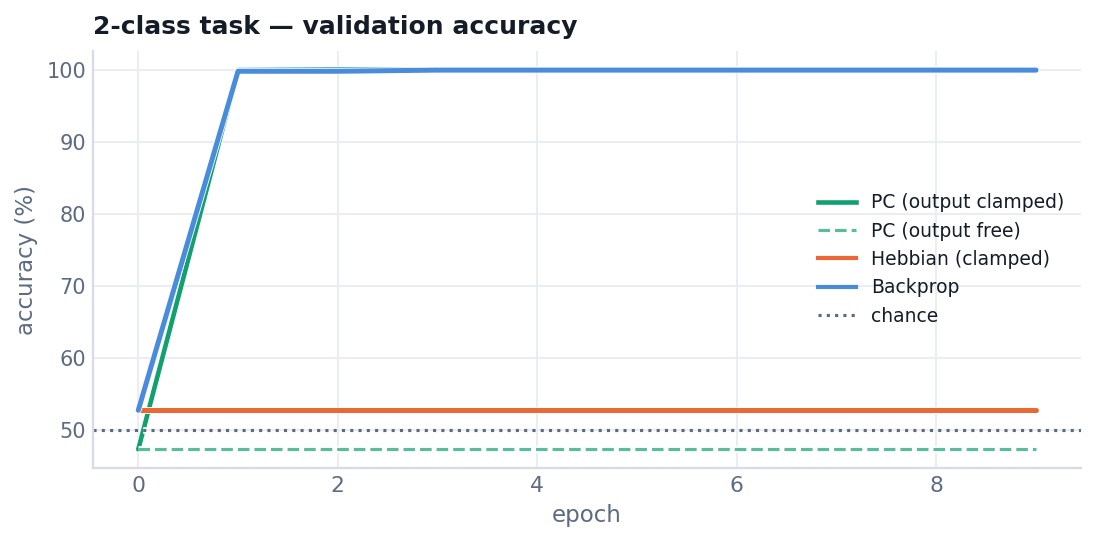<br><sub>2-class: PC (clamped) matches backprop; unclamped PC & Hebbian fail</sub>

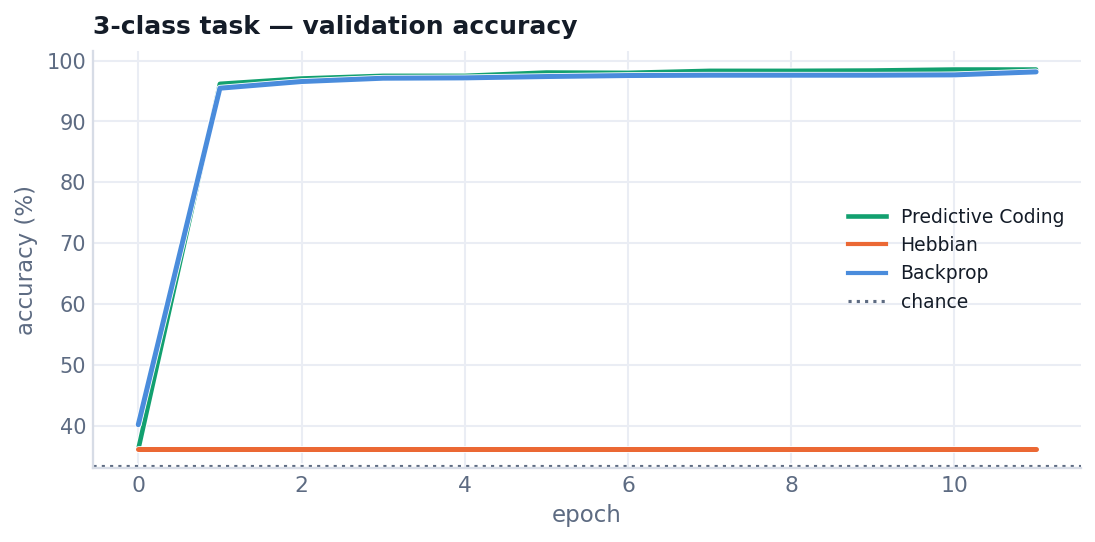<br><sub>3-class: PC vs Hebbian vs backprop validation accuracy</sub>

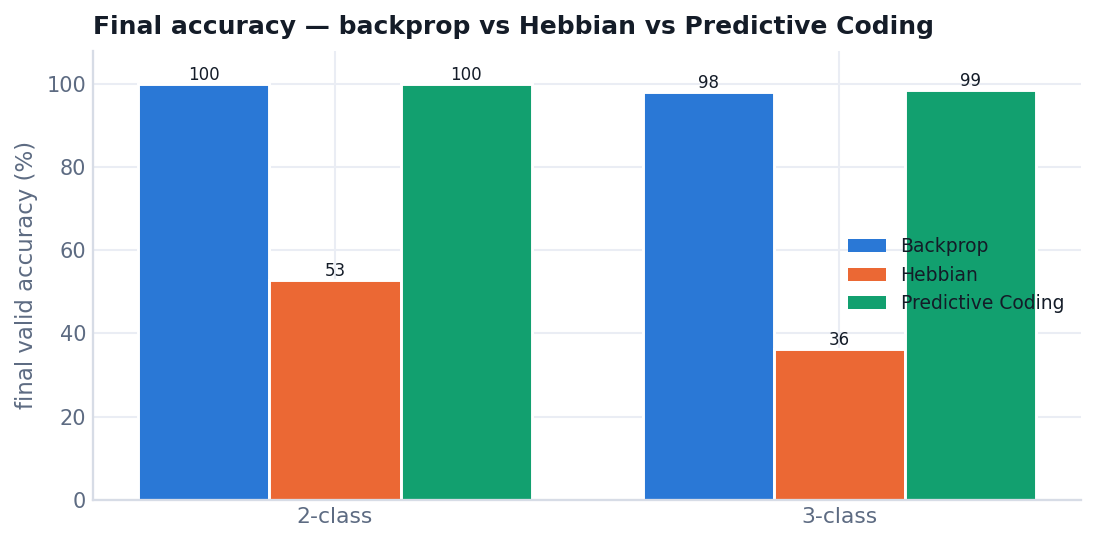<br><sub>Final accuracy by learning rule</sub>

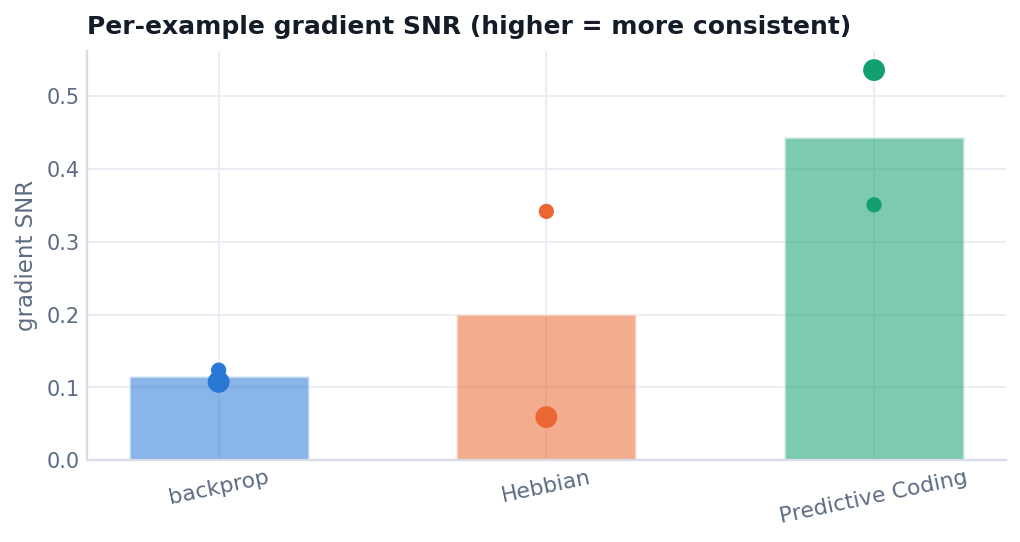<br><sub>Per-example gradient SNR — PC's updates are the most consistent</sub>

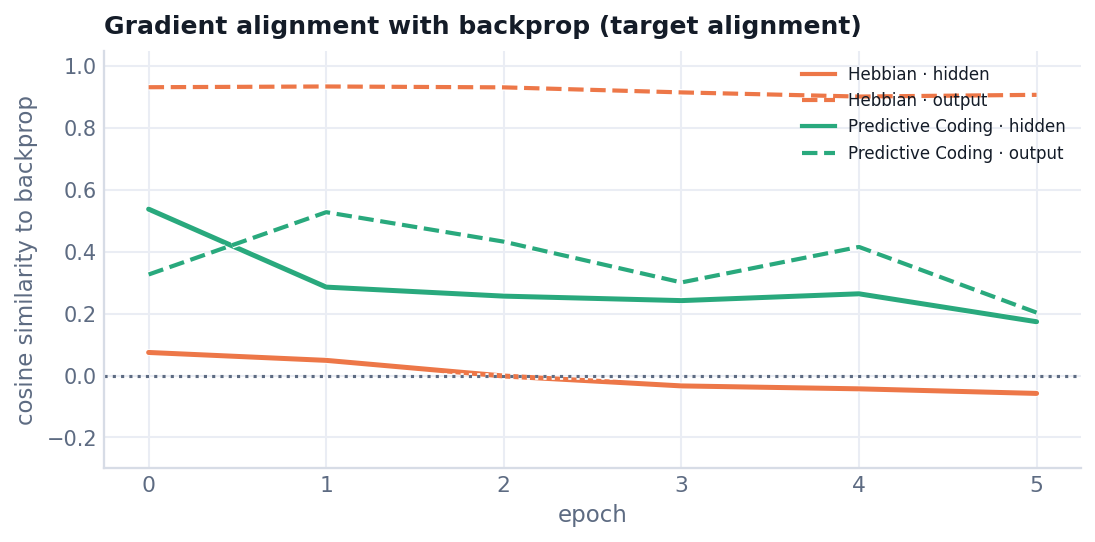<br><sub>Cosine alignment of each rule's update to the backprop gradient</sub>

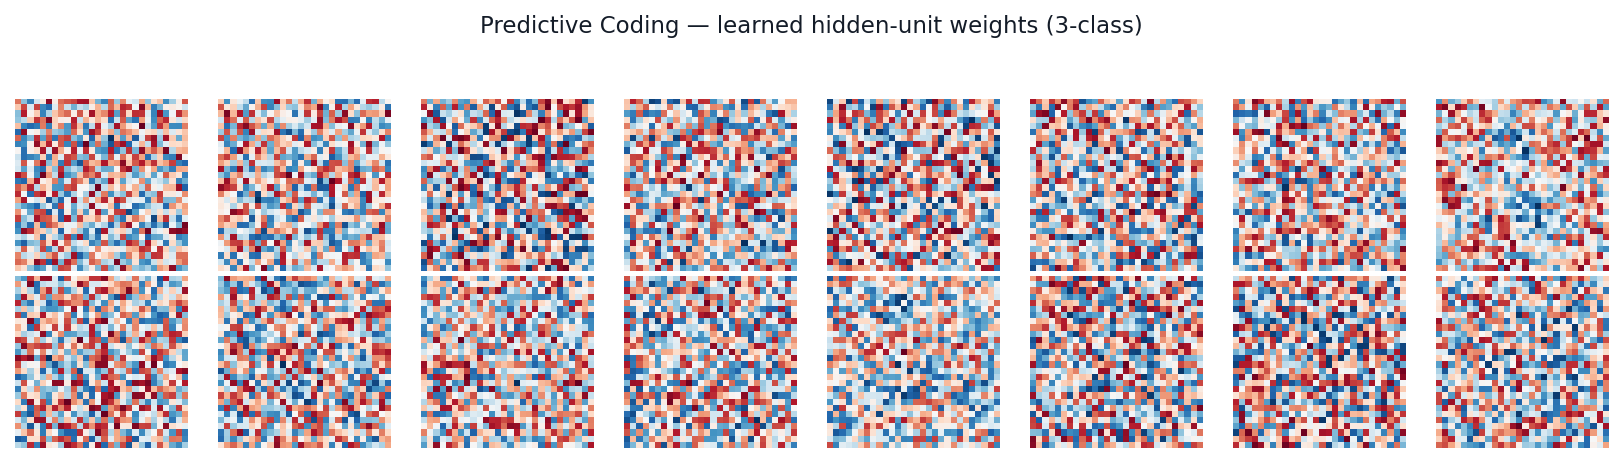<br><sub>Learned hidden-unit weight templates (PC)</sub>



**Read:** PC reaches backprop-level accuracy (98.5% vs 98.1% on 3-class) with **more consistent gradients** (higher SNR) and updates that stay well-aligned to backprop — while remaining fully local. Hebbian, lacking a target-driven error, lags badly.